# 00 — Exploratory Data Analysis
## MR Localization via Radio Fingerprinting

**Purpose.** This notebook constitutes Module 0 (M0) of the localization pipeline. Its goal is to characterize the two input datasets — `measurement_data.csv` (ray-tracing output) and `gcell_conf.csv` (cell configuration) — and derive empirically grounded design decisions for the downstream WKNN fingerprinting modules (M1–M4).

**Problem context.** LTE Measurement Reports (MRs) are anonymous: they carry RSRP values from observed cells but no GPS coordinates. The fingerprinting approach estimates position by matching each MR's RSRP vector against a pre-built database of reference fingerprints, where every entry maps a known grid position to its expected RSRP pattern across all 26 cells. The quality of this database — its spatial resolution, feature discriminability, and sparsity structure — directly bounds the achievable localization accuracy.

**Data source.** All measurements originate from ray-tracing simulation over an urban study area of approximately 1.23 km². Simulated RSRP is physically realistic but represents an optimistic upper bound relative to real drive-test data, as it does not include human body blockage, vehicle occlusion, or real antenna pattern imperfections.

**Notebook structure.**

| Section | Topic |
|---|---|
| §1 | Load & Overview |
| §2 | Data Quality Audit |
| §3 | RSRP Signal-Strength Distribution |
| §4 | Spatial Structure of the Study Area |
| §5 | Network Topology |
| §6 | Cell Visibility & Fingerprint Sparsity |
| §7 | Fingerprint Database Construction |
| §8 | Feature Discriminability via PCA |
| §9 | Key Findings & Design Decisions |

**Outputs.** All figures are saved to `../results/eda_*.png` for inclusion in the written report.

## 0. SETUP

In [33]:
# Standard library
import os
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine learning & statistics (used in §7–§8)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Input data paths (relative to notebooks/)
MEASUREMENT_DATA_PATH = '../data/raw/measurement_data.csv'
GCELL_CONF_PATH = '../data/raw/gcell_conf.csv'

# Ensure the results directory exists before any section writes figures
os.makedirs('../results', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load & Overview

This section loads the two input files and confirms their basic structure before any analysis begins.

| File | Description |
|---|---|
| `measurement_data.csv` | Long-format ray-tracing output. Each row is one `(UE position, cell, RSRP)` triple. This is the source for both the fingerprint DB (M1) and the query set (M2). |
| `gcell_conf.csv` | Static cell configuration: one row per LTE cell with its antenna coordinates, height, azimuth, and digital tilt. |

Both files are read once here and reused by all downstream sections.

In [34]:
# Load both input datasets once; all downstream sections reference these variables.
measurement_df = pd.read_csv(MEASUREMENT_DATA_PATH)
gcell_conf_df  = pd.read_csv(GCELL_CONF_PATH)

print(f"measurement_data : {measurement_df.shape[0]:,} rows × {measurement_df.shape[1]} columns")
print(f"gcell_conf       : {gcell_conf_df.shape[0]} rows × {gcell_conf_df.shape[1]} columns")

measurement_data : 41,481 rows × 7 columns
gcell_conf       : 26 rows × 8 columns


In [35]:
# measurement_data: structure and sample rows
print("=== measurement_data ===")
measurement_df.info()
measurement_df.head(5)

=== measurement_data ===
<class 'pandas.DataFrame'>
RangeIndex: 41481 entries, 0 to 41480
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ue_id      41481 non-null  str    
 1   sim_x      41481 non-null  float64
 2   sim_y      41481 non-null  float64
 3   date       41481 non-null  str    
 4   rsrp       41481 non-null  float64
 5   gcell_id   41481 non-null  str    
 6   ue_height  41481 non-null  float64
dtypes: float64(4), str(3)
memory usage: 2.2 MB


,ue_id,sim_x,sim_y,date,rsrp,gcell_id,ue_height
0,e3d3e5fb61d454ce8fc44cc8b94b0723,-126.868,-390.476,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500
1,e3d3e5fb61d454ce8fc44cc8b94b0723,-110.056,-343.944,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500
2,e3d3e5fb61d454ce8fc44cc8b94b0723,-66.343,-293.833,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500
3,e3d3e5fb61d454ce8fc44cc8b94b0723,-79.793,-309.941,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500
4,e3d3e5fb61d454ce8fc44cc8b94b0723,-103.331,-334.996,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500


In [36]:
# gcell_conf: structure and sample rows
print("=== gcell_conf ===")
gcell_conf_df.info()
gcell_conf_df.head(5)

=== gcell_conf ===
<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gcell_id        26 non-null     str    
 1   gnodeb_id       26 non-null     str    
 2   sim_x           26 non-null     float64
 3   sim_y           26 non-null     float64
 4   antenna_height  26 non-null     float64
 5   sync_date       26 non-null     str    
 6   digital_tilt    26 non-null     float64
 7   azimuth         26 non-null     float64
dtypes: float64(5), str(3)
memory usage: 1.8 KB


,gcell_id,gnodeb_id,sim_x,sim_y,antenna_height,sync_date,digital_tilt,azimuth
0,31c961ef3add553789472d3c8f142b8c,708fe16de58354bcb76c0442a910cab3,-705.664,-423.328,15.000,2026-04-01,6.000,46.499
1,445260e4d9e85a409ff8637aed4a0fb0,708fe16de58354bcb76c0442a910cab3,-705.664,-423.328,15.000,2026-04-01,6.000,321.136
2,f54c4e3c4b8c557fa19dc11b5cf7e1de,4b9330432d7c5003a0e8ed3166c7e289,-735.414,379.031,15.000,2026-04-01,6.000,43.922
3,b01a463a209e553b80729fa497d38f7e,4b9330432d7c5003a0e8ed3166c7e289,-735.414,379.031,15.000,2026-04-01,6.000,84.641
4,bdb144be0d005f64a1735f9b7731ee22,a01de0d8dc865dc2b525d3be3afb3b6f,-144.664,163.835,30.000,2026-04-01,6.000,55.409


## 2. Data Quality Audit

Before any modelling work, we perform a systematic integrity check across both datasets. This step (i) filters known simulation artefacts, (ii) validates that RSRP values fall within the physically plausible range for LTE signals (per 3GPP TS 36.133: −140 to −44 dBm), and (iii) confirms referential integrity between `measurement_data.csv` and `gcell_conf.csv`. A clean dataset is a prerequisite for a numerically sound fingerprint database.

In [37]:
# --- 2.1  Simulation artefact removal (rsrp == 0) ---
# Ray-tracing produces exactly-zero RSRP for positions the solver could not reach;
# these are invalid and must be dropped before building the fingerprint DB.
artifact_mask = measurement_df['rsrp'] == 0
print(f"Records with RSRP = 0 (simulation artefact) : {artifact_mask.sum()}")
measurement_df_clean = measurement_df[~artifact_mask].copy()
print(f"Records retained after filtering             : {len(measurement_df_clean):,}")

# --- 2.2  RSRP value-range validation ---
# LTE RSRP specification: −140 dBm (floor) to −44 dBm (ceiling, TS 36.133)
rsrp_min = measurement_df_clean['rsrp'].min()
rsrp_max = measurement_df_clean['rsrp'].max()
print(f"\nRSRP range   : [{rsrp_min:.1f}, {rsrp_max:.1f}] dBm")
n_strong = (measurement_df_clean['rsrp'] >= -50).sum()
n_weak   = (measurement_df_clean['rsrp'] <= -110).sum()
print(f"RSRP ≥ −50 dBm (near-field, UE very close to BTS) : {n_strong}")
print(f"RSRP ≤ −110 dBm (approaching sensitivity floor)   : {n_weak}")

# --- 2.3  Referential integrity: gcell_id cross-check ---
# Every cell ID in the measurements must exist in the configuration table;
# orphan IDs would cause silent NaN columns when building the fingerprint pivot.
meas_cells = set(measurement_df_clean['gcell_id'].unique())
conf_cells  = set(gcell_conf_df['gcell_id'].unique())
print(f"\nUnique cells in measurement_data  : {len(meas_cells)}")
print(f"Unique cells in gcell_conf         : {len(conf_cells)}")
print(f"Orphan in measurements (not in conf): {len(meas_cells - conf_cells)}  ← must be 0 for DB consistency")
print(f"Cells in conf not in measurements   : {len(conf_cells - meas_cells)}"
      "  (cells simulated but not measured at any grid point)")

# --- 2.4  Dataset scope summary ---
n_unique_pos = measurement_df_clean.groupby(['sim_x', 'sim_y']).ngroups
n_unique_ue  = measurement_df_clean['ue_id'].nunique()
n_unique_ev  = measurement_df_clean.groupby(['ue_id', 'date']).ngroups
print(f"\nUnique (sim_x, sim_y) reference positions : {n_unique_pos:,}")
print(f"Unique UE identifiers                      : {n_unique_ue:,}")
print(f"Unique (ue_id, date) measurement events    : {n_unique_ev:,}")
print(f"Avg records per reference position         : {len(measurement_df_clean)/n_unique_pos:.1f}")

Records with RSRP = 0 (simulation artefact) : 6
Records retained after filtering             : 41,475

RSRP range   : [-117.0, -42.0] dBm
RSRP ≥ −50 dBm (near-field, UE very close to BTS) : 17
RSRP ≤ −110 dBm (approaching sensitivity floor)   : 447

Unique cells in measurement_data  : 26
Unique cells in gcell_conf         : 26
Orphan in measurements (not in conf): 0  ← must be 0 for DB consistency
Cells in conf not in measurements   : 0  (cells simulated but not measured at any grid point)

Unique (sim_x, sim_y) reference positions : 8,403
Unique UE identifiers                      : 1,490
Unique (ue_id, date) measurement events    : 7,919
Avg records per reference position         : 4.9


## 3. RSRP Signal-Strength Distribution

RSRP (Reference Signal Received Power, in dBm) is the fundamental observable in this localisation system. Each cell contributes one dimension to the fingerprint vector, and the marginal distribution of that cell's RSRP across all reference positions directly governs its discriminative contribution: a cell whose RSRP varies broadly across the study area provides a more informative feature than one that is nearly constant. We examine:

1. The **aggregate distribution** of all RSRP measurements (histogram + KDE + empirical CDF)
2. **Per-cell statistics** (ordered boxplots) to identify cells with high vs. low spatial variability
3. **Inter-cell median spread** as a proxy for cross-cell discriminability

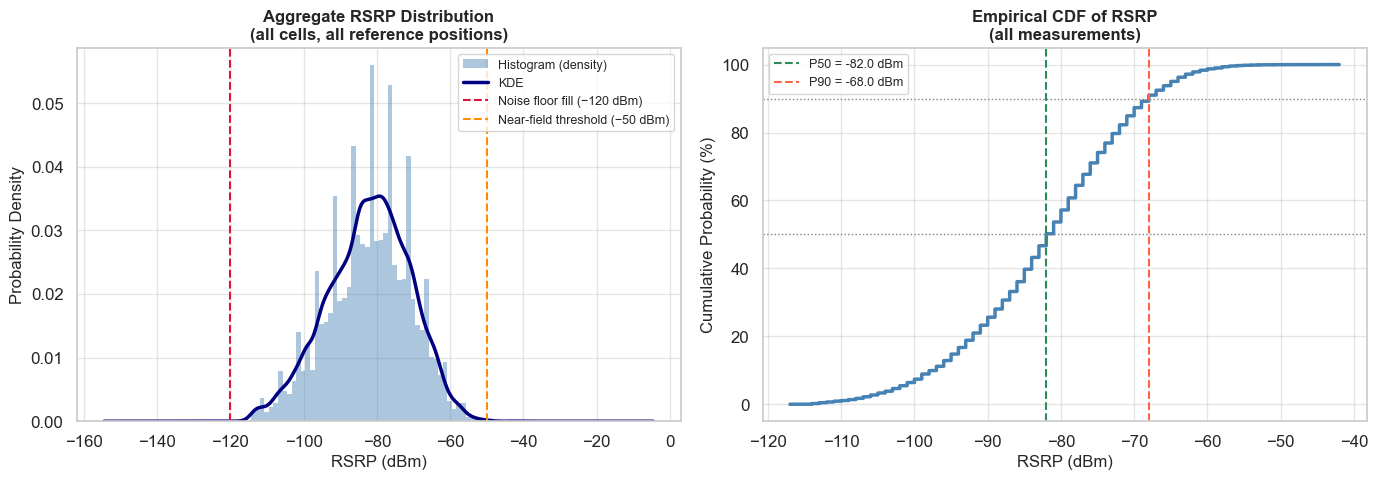

Descriptive statistics — all measurement records:
count   41475.000
mean      -82.193
std        11.290
min      -117.000
25%       -90.000
50%       -82.000
75%       -74.000
max       -42.000

Dynamic range (max − min): 75.0 dB  (larger range → more information per cell)


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rsrp_vals = measurement_df_clean['rsrp']
rsrp_min  = rsrp_vals.min()
rsrp_max  = rsrp_vals.max()

# — Histogram + KDE —
ax = axes[0]
ax.hist(rsrp_vals, bins=60, density=True, alpha=0.45, color='steelblue',
        edgecolor='none', label='Histogram (density)')
rsrp_vals.plot.kde(ax=ax, color='navy', linewidth=2.5, label='KDE')
ax.axvline(-120, color='crimson',    linestyle='--', linewidth=1.5, label='Noise floor fill (−120 dBm)')
ax.axvline(-50,  color='darkorange', linestyle='--', linewidth=1.5, label='Near-field threshold (−50 dBm)')
ax.set_xlabel('RSRP (dBm)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Aggregate RSRP Distribution\n(all cells, all reference positions)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# — Empirical CDF —
ax2 = axes[1]
sorted_rsrp = np.sort(rsrp_vals)
cdf = np.arange(1, len(sorted_rsrp) + 1) / len(sorted_rsrp)
ax2.plot(sorted_rsrp, cdf * 100, color='steelblue', linewidth=2.5)
for pct, col in [(50, 'seagreen'), (90, 'tomato')]:
    val = np.percentile(sorted_rsrp, pct)
    ax2.axhline(pct, color='gray', linestyle=':', linewidth=1)
    ax2.axvline(val, color=col, linestyle='--', linewidth=1.5, label=f'P{pct} = {val:.1f} dBm')
ax2.set_xlabel('RSRP (dBm)', fontsize=12)
ax2.set_ylabel('Cumulative Probability (%)', fontsize=12)
ax2.set_title('Empirical CDF of RSRP\n(all measurements)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../results/eda_rsrp_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Descriptive statistics — all measurement records:")
print(measurement_df_clean['rsrp'].describe().to_string())
print(f"\nDynamic range (max − min): {rsrp_max - rsrp_min:.1f} dB  "
      "(larger range → more information per cell)")

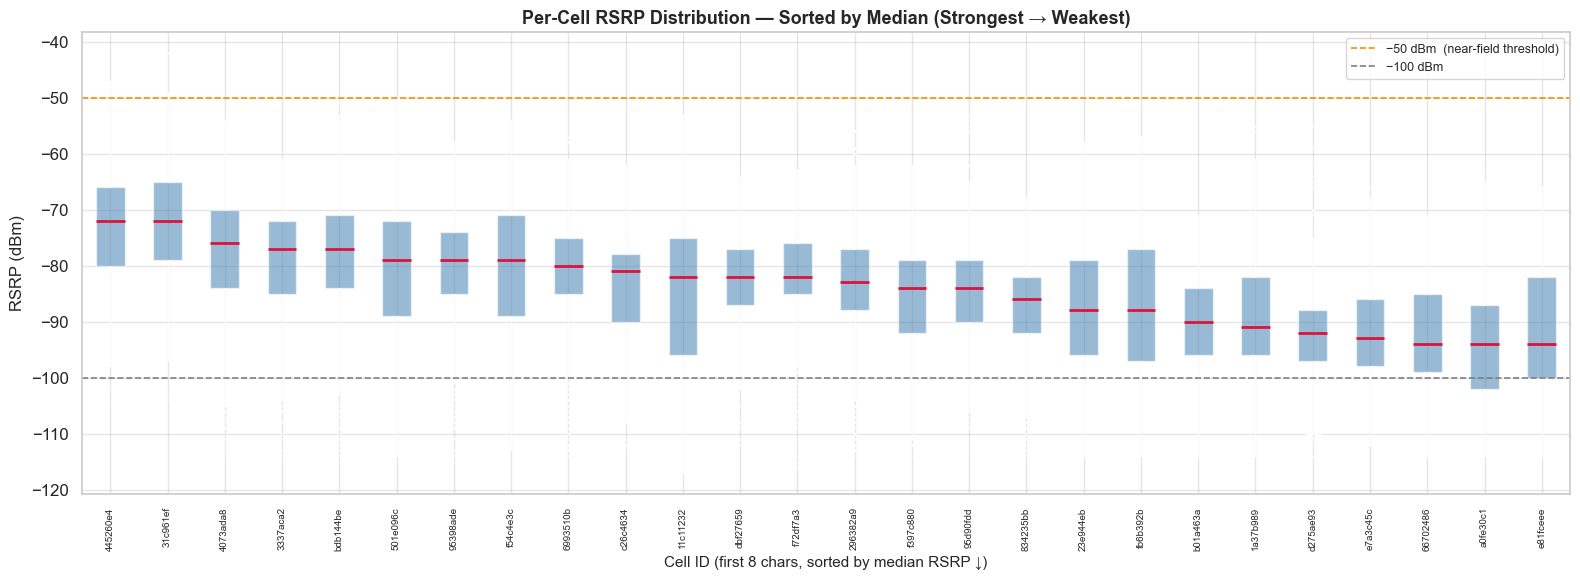

Cell with highest median RSRP : 445260e4…  →  -72.0 dBm
Cell with lowest  median RSRP : e81fceee…  →  -94.0 dBm
Inter-cell median spread       : 22.0 dB  (large spread → high inter-cell discriminability)

Mean within-cell IQR : 13.5 dB  (measures spatial RSRP variation per cell)


In [39]:
# Sort cells by median RSRP (strongest → weakest)
cell_medians = (
    measurement_df_clean
    .groupby('gcell_id')['rsrp']
    .median()
    .sort_values(ascending=False)
)
ordered_cells = cell_medians.index.tolist()
data_by_cell  = [measurement_df_clean.loc[measurement_df_clean['gcell_id'] == c, 'rsrp'].values
                 for c in ordered_cells]
short_labels  = [c[:8] for c in ordered_cells]

fig, ax = plt.subplots(figsize=(16, 6))
bp = ax.boxplot(data_by_cell, patch_artist=True, notch=False,
                medianprops=dict(color='crimson', linewidth=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3, color='gray'))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.55)

ax.set_xticks(range(1, len(ordered_cells) + 1))
ax.set_xticklabels(short_labels, rotation=90, fontsize=7)
ax.set_xlabel('Cell ID (first 8 chars, sorted by median RSRP ↓)', fontsize=11)
ax.set_ylabel('RSRP (dBm)', fontsize=12)
ax.set_title('Per-Cell RSRP Distribution — Sorted by Median (Strongest → Weakest)',
             fontsize=13, fontweight='bold')
ax.axhline(-50,  color='darkorange', linestyle='--', linewidth=1.2, label='−50 dBm  (near-field threshold)')
ax.axhline(-100, color='gray',       linestyle='--', linewidth=1.2, label='−100 dBm')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../results/eda_rsrp_per_cell.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Cell with highest median RSRP : {ordered_cells[0][:8]}…  →  {cell_medians.iloc[0]:.1f} dBm")
print(f"Cell with lowest  median RSRP : {ordered_cells[-1][:8]}…  →  {cell_medians.iloc[-1]:.1f} dBm")
print(f"Inter-cell median spread       : {cell_medians.iloc[0] - cell_medians.iloc[-1]:.1f} dB"
      "  (large spread → high inter-cell discriminability)")

cell_iqr = (
    measurement_df_clean
    .groupby('gcell_id')['rsrp']
    .quantile([0.25, 0.75])
    .unstack()
)
cell_iqr['IQR'] = cell_iqr[0.75] - cell_iqr[0.25]
print(f"\nMean within-cell IQR : {cell_iqr['IQR'].mean():.1f} dB"
      "  (measures spatial RSRP variation per cell)")

## 4. Spatial Structure of the Study Area

The density and regularity of the reference measurement grid determine the spatial resolution of the fingerprint database. WKNN localisation accuracy is bounded by the average inter-point spacing: if the $K$ nearest fingerprints in feature space correspond to reference positions spread across a 50 m radius, the weighted centroid estimate can still carry a 50 m baseline error regardless of RSRP discriminability. We characterise the geographic extent, grid density, and spatial homogeneity of the study area.

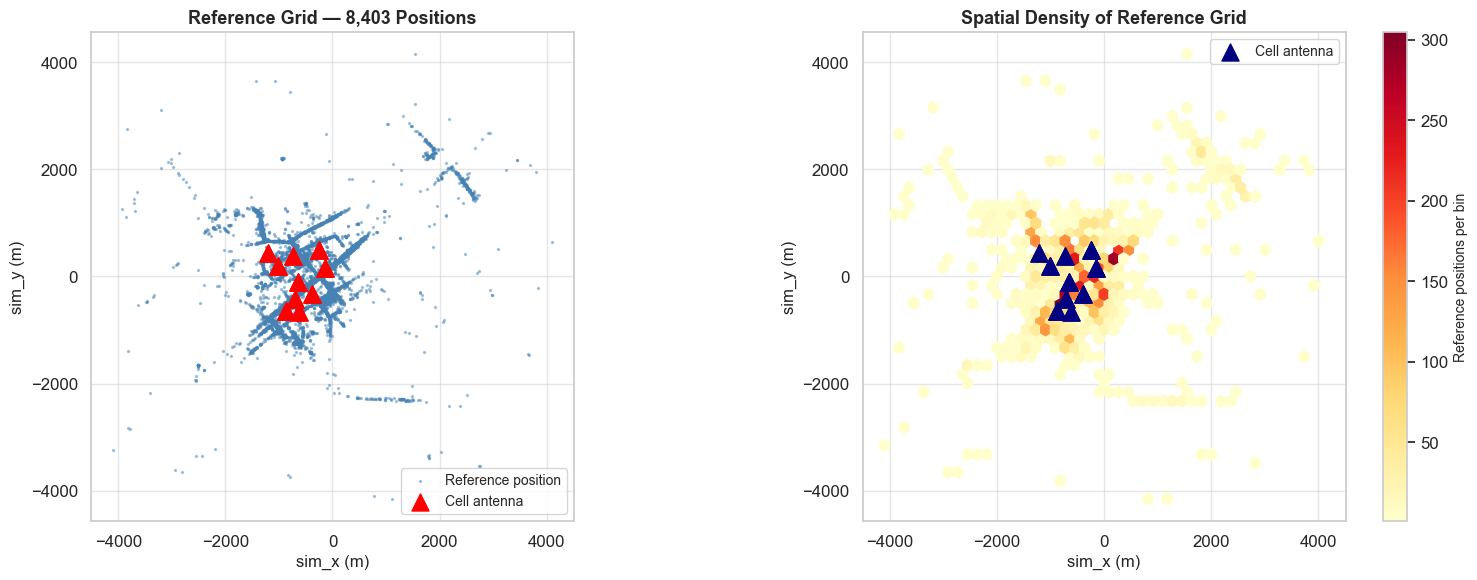

Study area extent       : 8191 m (E–W)  ×  8297 m (N–S)
Bounding-box area       : 67.963 km²
Total reference positions: 8,403
Areal density           : 124 positions/km²
Equivalent uniform grid : ~89.9 m inter-point spacing

sim_x range: [-4095.1, 4096.2] m
sim_y range: [-4148.8, 4148.2] m


In [40]:
unique_pos = measurement_df_clean.drop_duplicates(subset=['sim_x', 'sim_y'])[['sim_x', 'sim_y']].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# — Scatter of all reference positions —
ax = axes[0]
ax.scatter(unique_pos['sim_x'], unique_pos['sim_y'],
           s=2, alpha=0.4, color='steelblue', rasterized=True, label='Reference position')
ax.scatter(gcell_conf_df['sim_x'], gcell_conf_df['sim_y'],
           s=150, color='red', marker='^', zorder=5, label='Cell antenna')
ax.set_xlabel('sim_x (m)', fontsize=12)
ax.set_ylabel('sim_y (m)', fontsize=12)
ax.set_title(f'Reference Grid — {len(unique_pos):,} Positions', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_aspect('equal')

# — 2-D hexbin density map —
ax2 = axes[1]
hb = ax2.hexbin(unique_pos['sim_x'], unique_pos['sim_y'],
                gridsize=45, cmap='YlOrRd', mincnt=1)
cb = plt.colorbar(hb, ax=ax2)
cb.set_label('Reference positions per bin', fontsize=10)
ax2.scatter(gcell_conf_df['sim_x'], gcell_conf_df['sim_y'],
            s=150, color='navy', marker='^', zorder=5, label='Cell antenna')
ax2.set_xlabel('sim_x (m)', fontsize=12)
ax2.set_ylabel('sim_y (m)', fontsize=12)
ax2.set_title('Spatial Density of Reference Grid', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig('../results/eda_spatial_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

x_range  = unique_pos['sim_x'].max() - unique_pos['sim_x'].min()
y_range  = unique_pos['sim_y'].max() - unique_pos['sim_y'].min()
area_km2 = (x_range * y_range) / 1e6
avg_spacing = np.sqrt(area_km2 * 1e6 / len(unique_pos))

print(f"Study area extent       : {x_range:.0f} m (E–W)  ×  {y_range:.0f} m (N–S)")
print(f"Bounding-box area       : {area_km2:.3f} km²")
print(f"Total reference positions: {len(unique_pos):,}")
print(f"Areal density           : {len(unique_pos)/area_km2:.0f} positions/km²")
print(f"Equivalent uniform grid : ~{avg_spacing:.1f} m inter-point spacing")
print(f"\nsim_x range: [{unique_pos['sim_x'].min():.1f}, {unique_pos['sim_x'].max():.1f}] m")
print(f"sim_y range: [{unique_pos['sim_y'].min():.1f}, {unique_pos['sim_y'].max():.1f}] m")

## 5. Network Topology

The spatial configuration of gNodeBs and their sector azimuths governs the RSRP field structure across the study area. A 3-sector site creates three directional, partially-overlapping coverage footprints that together tile the surrounding area with distinct RSRP patterns. Cells whose boresight directions are well-distributed across the azimuth compass will produce the most spatially varied — and therefore most discriminative — RSRP gradients.

Two antenna height tiers are present in this dataset: ground-level sites (15 m) and elevated sites (30 m). Elevated antennas produce broader coverage footprints but potentially weaker spatial RSRP gradients near the antenna, which may limit discriminability in their immediate vicinity.

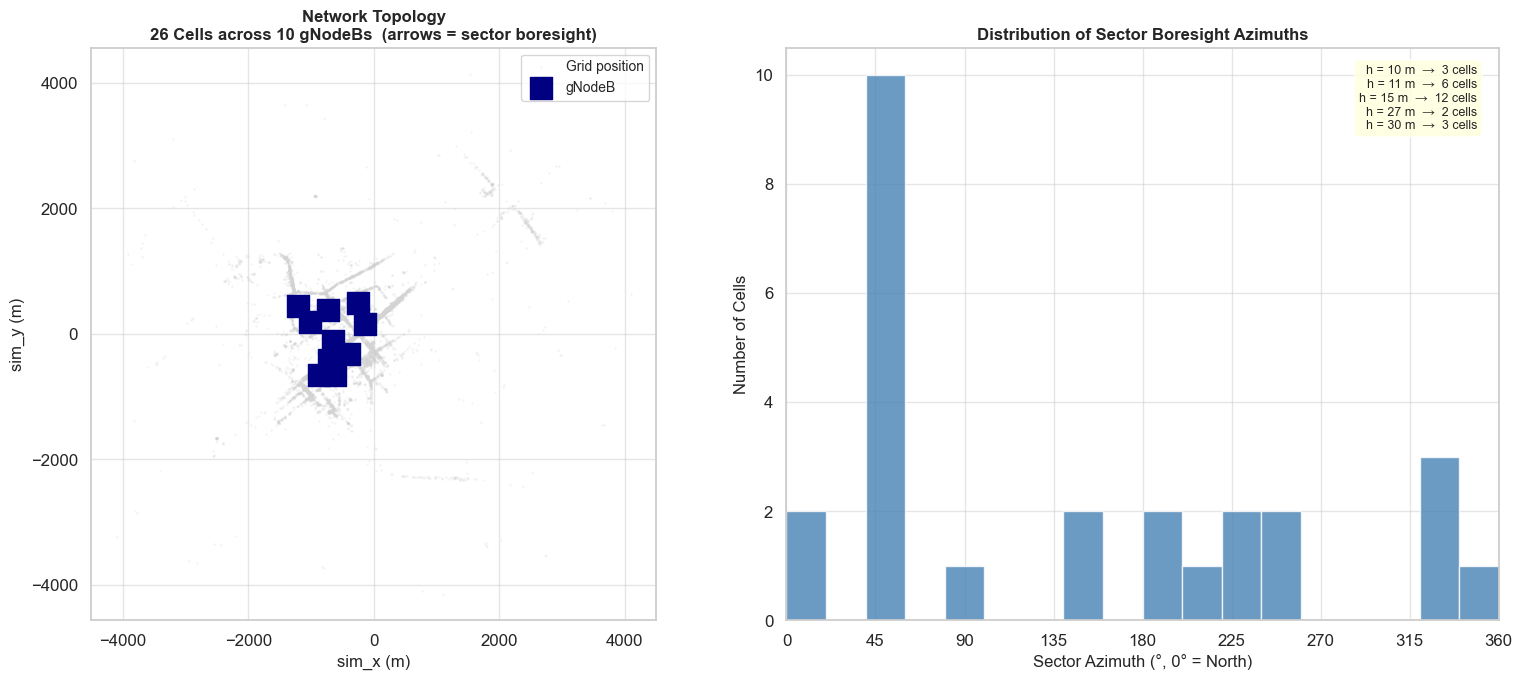

Per-gNodeB summary:
  gnodeb_id  n_cells  h_ant  mean_tilt
1b1f14b6...        2 27.000      6.000
4b933043...        2 15.000      6.000
708fe16d...        2 15.000      6.000
a01de0d8...        3 30.000      6.667
a4a6ffcd...        3 10.000      6.667
a7fba16a...        2 15.000      7.000
bbb56a4a...        3 11.000      7.000
db390f71...        3 15.000      6.000
e42d434f...        3 11.000      6.000
fe3ea5bf...        3 15.000      6.000

Azimuth range: [7.5°, 347.1°]
Digital tilt  : all cells = [6. 9. 8.] °


In [41]:
def az_to_arrow(az_deg, length=90):
    """Convert geographic azimuth (0°=North, clockwise) to (dx, dy) Cartesian vector."""
    rad = np.radians(90.0 - az_deg)
    return np.cos(rad) * length, np.sin(rad) * length

gnodeb_pos = gcell_conf_df.groupby('gnodeb_id')[['sim_x', 'sim_y']].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# — Cell positions + sector azimuth arrows —
ax = axes[0]
ax.scatter(unique_pos['sim_x'], unique_pos['sim_y'],
           s=1, alpha=0.15, color='lightgray', rasterized=True, zorder=0, label='Grid position')
ax.scatter(gnodeb_pos['sim_x'], gnodeb_pos['sim_y'],
           s=250, color='navy', marker='s', zorder=5, label='gNodeB')

cell_colors = plt.cm.tab10(np.linspace(0, 0.9, len(gcell_conf_df)))
for i, (_, row) in enumerate(gcell_conf_df.iterrows()):
    dx, dy = az_to_arrow(row['azimuth'], length=90)
    ax.annotate('', xy=(row['sim_x'] + dx, row['sim_y'] + dy),
                xytext=(row['sim_x'], row['sim_y']),
                arrowprops=dict(arrowstyle='->', color=cell_colors[i], lw=2.2))

ax.set_xlabel('sim_x (m)', fontsize=12)
ax.set_ylabel('sim_y (m)', fontsize=12)
ax.set_title(f'Network Topology\n{len(gcell_conf_df)} Cells across {len(gnodeb_pos)} gNodeBs  '
             f'(arrows = sector boresight)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_aspect('equal')

# — Sector azimuth histogram —
ax2 = axes[1]
ax2.hist(gcell_conf_df['azimuth'], bins=18, range=(0, 360),
         color='steelblue', edgecolor='white', alpha=0.8)
ax2.set_xlabel('Sector Azimuth (°, 0° = North)', fontsize=12)
ax2.set_ylabel('Number of Cells', fontsize=12)
ax2.set_xlim(0, 360)
ax2.set_xticks(range(0, 361, 45))
ax2.set_title('Distribution of Sector Boresight Azimuths', fontsize=12, fontweight='bold')

height_info = gcell_conf_df.groupby('antenna_height')['gcell_id'].count()
info_str = '\n'.join([f"h = {h:.0f} m  →  {n} cells" for h, n in height_info.items()])
ax2.text(0.97, 0.97, info_str, transform=ax2.transAxes, fontsize=9,
         va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.85))

plt.tight_layout()
plt.savefig('../results/eda_network_topology.png', dpi=150, bbox_inches='tight')
plt.show()

print("Per-gNodeB summary:")
gnodeb_summary = (
    gcell_conf_df
    .groupby('gnodeb_id')
    .agg(n_cells=('gcell_id', 'count'),
         h_ant=('antenna_height', 'first'),
         mean_tilt=('digital_tilt', 'mean'))
    .reset_index()
)
gnodeb_summary['gnodeb_id'] = gnodeb_summary['gnodeb_id'].str[:8] + '...'
print(gnodeb_summary.to_string(index=False))
print(f"\nAzimuth range: [{gcell_conf_df['azimuth'].min():.1f}°, {gcell_conf_df['azimuth'].max():.1f}°]")
print(f"Digital tilt  : all cells = {gcell_conf_df['digital_tilt'].unique()} °")

## 6. Cell Visibility and Fingerprint Sparsity

**Cell visibility** — the number of distinct cells simultaneously observable from a given position — is the primary determinant of fingerprint uniqueness. In the WKNN framework, a query fingerprint with $n_\text{obs} < C$ observed cells produces a sparse vector: the remaining $C - n_\text{obs}$ dimensions are set to the noise-floor constant (−120 dBm). When $n_\text{obs}$ is small, the Euclidean distance in the full $C$-dimensional space is dominated by these fill dimensions rather than by the signal-bearing dimensions, systematically reducing the discriminative power of the measured cells.

We quantify sparsity at two levels:
- **Reference level**: cells visible per grid position (governs fingerprint DB sparsity)
- **Query level**: cells per simulated measurement event (governs query sparsity at inference time)

The spatial distribution of cell visibility is also mapped to identify geographic zones prone to fingerprint ambiguity.

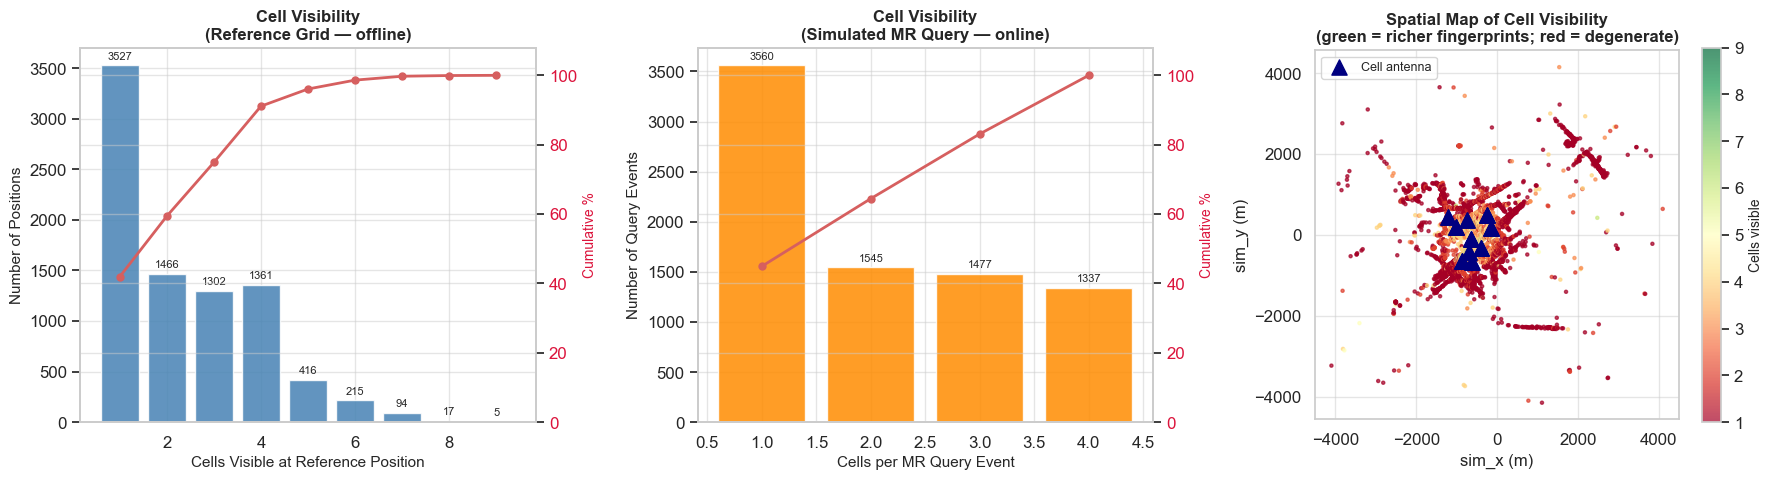

Cell visibility at reference positions:
n_positions   8403.000
mean             2.382
std              1.521
min              1.000
25%              1.000
50%              2.000
75%              4.000
max              9.000

Positions with only 1 cell visible : 3,527 (42.0%)  ← degenerate fingerprints
Positions with 2–3 cells           : 2,768 (32.9%)
Positions with 4+ cells            : 2,108 (25.1%)  ← rich, discriminative fingerprints

Query event cell-count statistics:
n_events   7919.000
mean          2.075
std           1.143
min           1.000
25%           1.000
50%           2.000
75%           3.000
max           4.000


In [42]:
# — Cells per reference grid position (offline fingerprint DB) —
cells_per_pos = (
    measurement_df_clean
    .groupby(['sim_x', 'sim_y'])['gcell_id']
    .nunique()
    .reset_index(name='n_cells')
)

# — Cells per simulated MR query event (online query at inference time) —
cells_per_query = (
    measurement_df_clean
    .groupby(['ue_id', 'date'])['gcell_id']
    .nunique()
    .reset_index(name='n_cells')
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — (A) Cells per reference position —
ax = axes[0]
pos_counts = cells_per_pos['n_cells'].value_counts().sort_index()
bars = ax.bar(pos_counts.index, pos_counts.values,
              color='steelblue', edgecolor='white', alpha=0.85)
ax.bar_label(bars, fmt='%d', fontsize=8, padding=3)
cdf_pos  = pos_counts.cumsum() / pos_counts.sum()
ax_r = ax.twinx()
ax_r.plot(cdf_pos.index, cdf_pos.values * 100, 'r-o', lw=2, ms=5)
ax_r.set_ylabel('Cumulative %', color='crimson', fontsize=10)
ax_r.tick_params(axis='y', labelcolor='crimson')
ax_r.set_ylim(0, 108)
ax.set_xlabel('Cells Visible at Reference Position', fontsize=11)
ax.set_ylabel('Number of Positions', fontsize=11)
ax.set_title('Cell Visibility\n(Reference Grid — offline)', fontsize=12, fontweight='bold')

# — (B) Cells per MR query event —
ax2 = axes[1]
qcounts = cells_per_query['n_cells'].value_counts().sort_index()
bars2 = ax2.bar(qcounts.index, qcounts.values,
                color='darkorange', edgecolor='white', alpha=0.85)
ax2.bar_label(bars2, fmt='%d', fontsize=8, padding=3)
cdf_q  = qcounts.cumsum() / qcounts.sum()
ax2_r = ax2.twinx()
ax2_r.plot(cdf_q.index, cdf_q.values * 100, 'r-o', lw=2, ms=5)
ax2_r.set_ylabel('Cumulative %', color='crimson', fontsize=10)
ax2_r.tick_params(axis='y', labelcolor='crimson')
ax2_r.set_ylim(0, 108)
ax2.set_xlabel('Cells per MR Query Event', fontsize=11)
ax2.set_ylabel('Number of Query Events', fontsize=11)
ax2.set_title('Cell Visibility\n(Simulated MR Query — online)', fontsize=12, fontweight='bold')

# — (C) Spatial map of cell visibility —
ax3 = axes[2]
sc = ax3.scatter(cells_per_pos['sim_x'], cells_per_pos['sim_y'],
                 c=cells_per_pos['n_cells'], cmap='RdYlGn',
                 s=5, alpha=0.7, vmin=1, vmax=cells_per_pos['n_cells'].max(),
                 rasterized=True)
cb = plt.colorbar(sc, ax=ax3)
cb.set_label('Cells visible', fontsize=10)
ax3.scatter(gcell_conf_df['sim_x'], gcell_conf_df['sim_y'],
            s=120, color='navy', marker='^', zorder=5, label='Cell antenna')
ax3.set_xlabel('sim_x (m)', fontsize=12)
ax3.set_ylabel('sim_y (m)', fontsize=12)
ax3.set_title('Spatial Map of Cell Visibility\n(green = richer fingerprints; red = degenerate)',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.set_aspect('equal')

plt.tight_layout()
plt.savefig('../results/eda_cell_visibility.png', dpi=150, bbox_inches='tight')
plt.show()

n_pos = len(cells_per_pos)
print("Cell visibility at reference positions:")
print(cells_per_pos['n_cells'].describe().rename({'count': 'n_positions'}).to_string())
print(f"\nPositions with only 1 cell visible : {(cells_per_pos['n_cells']==1).sum():,} "
      f"({(cells_per_pos['n_cells']==1).mean()*100:.1f}%)  ← degenerate fingerprints")
print(f"Positions with 2–3 cells           : "
      f"{((cells_per_pos['n_cells']>=2)&(cells_per_pos['n_cells']<=3)).sum():,} "
      f"({((cells_per_pos['n_cells']>=2)&(cells_per_pos['n_cells']<=3)).mean()*100:.1f}%)")
print(f"Positions with 4+ cells            : {(cells_per_pos['n_cells']>=4).sum():,} "
      f"({(cells_per_pos['n_cells']>=4).mean()*100:.1f}%)  ← rich, discriminative fingerprints")
print("\nQuery event cell-count statistics:")
print(cells_per_query['n_cells'].describe().rename({'count': 'n_events'}).to_string())

## 7. Fingerprint Database Construction and Sparsity Analysis

The fingerprint database $\mathbf{F} \in \mathbb{R}^{P \times C}$ is constructed by pivoting the long-format measurement table: group records by reference position $(s_x, s_y)$, unstack `gcell_id` as the column axis, and aggregate with mean RSRP (averaging across all UEs that visited the same grid point). Positions where a given cell was never measured — because it was below the sensitivity threshold or outside the cell's coverage lobe — are filled with $-120$ dBm, the assumed thermal noise floor.

We analyse the resulting matrix for:
1. **Overall fill ratio** (aggregate sparsity)
2. **Per-cell spatial coverage** (fraction of positions where each cell provides a real observation)
3. **Pairwise RSRP correlation** between cells (reveals redundant vs. complementary spatial information)

In [43]:
# Build fingerprint database — mirrors the M1 (build_fp_db) pipeline step exactly.
# Long-format → pivot (gcell_id as columns) → mean-aggregate → fill missing with noise floor.
fp_db = (
    measurement_df_clean
    .groupby(['sim_x', 'sim_y', 'gcell_id'])['rsrp']
    .mean()
    .unstack('gcell_id')
    .reset_index()
    .fillna(-120.0)
)
cell_cols = [c for c in fp_db.columns if c not in ['sim_x', 'sim_y']]
X_fp      = fp_db[cell_cols].values
FILL_VAL  = -120.0

print(f"Fingerprint DB shape : {X_fp.shape}  "
      f"({len(fp_db)} reference positions  ×  {len(cell_cols)} cell features)")
print(f"DataFrame memory     : {fp_db.memory_usage(deep=True).sum() / 1024:.1f} KB")

n_filled = (X_fp == FILL_VAL).sum()
n_total  = X_fp.size
sparsity = n_filled / n_total * 100
print(f"\nFill (−120 dBm) entries : {n_filled:,} / {n_total:,}  ({sparsity:.1f}%  — fingerprint sparsity)")
print(f"Observed entries        : {n_total - n_filled:,}  ({100 - sparsity:.1f}%)")

# Per-cell spatial coverage: fraction of grid positions where each cell was actually measured.
cell_coverage = pd.Series(
    (X_fp > FILL_VAL).mean(axis=0) * 100,
    index=cell_cols,
    name='coverage_%'
).sort_values(ascending=False)

print(f"\nPer-cell spatial coverage  (% of {len(fp_db)} grid positions):")
print(f"{'Cell ID (8ch)':<14}  {'Coverage':>9}")
print('─' * 30)
for cid, cov in cell_coverage.items():
    bar = '█' * int(cov / 5)
    print(f"{cid[:8] + '...':14}  {cov:8.1f}%  {bar}")

print(f"\nMean per-cell coverage : {cell_coverage.mean():.1f}%")
print(f"Minimum coverage       : {cell_coverage.min():.1f}%  ← most spatially limited cell")
print(f"Maximum coverage       : {cell_coverage.max():.1f}%  ← widest-coverage cell")

Fingerprint DB shape : (8403, 26)  (8403 reference positions  ×  26 cell features)
DataFrame memory     : 1838.3 KB

Fill (−120 dBm) entries : 198,460 / 218,478  (90.8%  — fingerprint sparsity)
Observed entries        : 20,018  (9.2%)

Per-cell spatial coverage  (% of 8403 grid positions):
Cell ID (8ch)    Coverage
──────────────────────────────
4073ada8...         24.5%  ████
bdb144be...         18.2%  ███
296382a9...         15.0%  ██
95398ade...         13.7%  ██
31c961ef...         12.8%  ██
6993510b...         12.3%  ██
3337aca2...         12.3%  ██
834235bb...         12.2%  ██
445260e4...         10.9%  ██
501e096c...         10.5%  ██
f54c4e3c...          9.5%  █
fb6b392b...          9.3%  █
e81fceee...          7.7%  █
c26c4634...          7.7%  █
f397c880...          7.4%  █
95d90fdd...          7.0%  █
f72df7a3...          6.6%  █
11c11232...          6.3%  █
1a37b989...          6.2%  █
dbf27659...          6.1%  █
b01a463a...          5.5%  █
d275ae93...          4.4%  
23

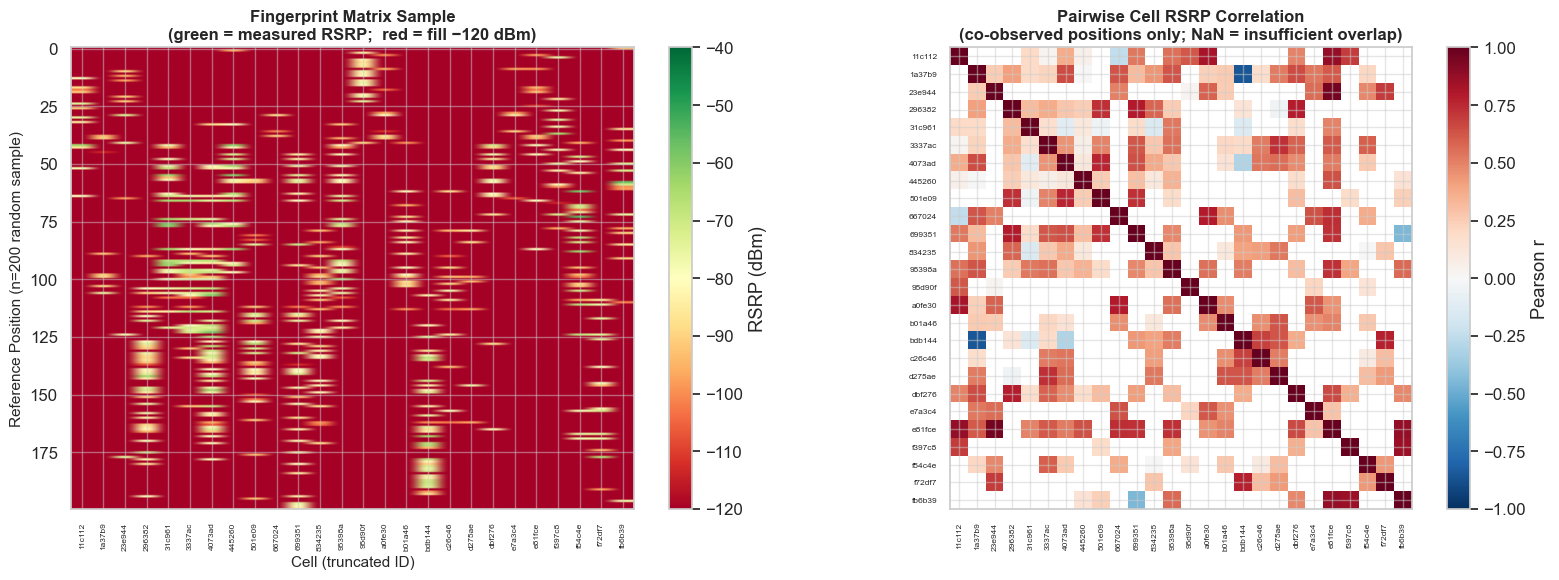

Pairwise correlation summary (upper triangle, 146 valid pairs):
  Mean |r|       : 0.420
  Max  r         : 0.958  ← most co-varying pair
  Min  r         : -0.853  ← most anti-correlated pair
  |r| > 0.7 pairs: 17  (high redundancy)
  |r| < 0.3 pairs: 51  (near-independent information)


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
short_labels = [c[:6] for c in cell_cols]

# — Fingerprint matrix sample (200 random rows) —
rng = np.random.default_rng(42)
sample_idx = np.sort(rng.choice(len(X_fp), size=min(200, len(X_fp)), replace=False))
X_sample = X_fp[sample_idx]

ax = axes[0]
im = ax.imshow(X_sample, aspect='auto', cmap='RdYlGn', vmin=-120, vmax=-40)
plt.colorbar(im, ax=ax, label='RSRP (dBm)')
ax.set_xticks(range(len(cell_cols)))
ax.set_xticklabels(short_labels, rotation=90, fontsize=6)
ax.set_xlabel('Cell (truncated ID)', fontsize=11)
ax.set_ylabel('Reference Position (n=200 random sample)', fontsize=11)
ax.set_title('Fingerprint Matrix Sample\n(green = measured RSRP;  red = fill −120 dBm)', fontsize=12, fontweight='bold')

# — Cell-to-cell RSRP Pearson correlation (co-observed positions only) —
# For each cell pair (i,j), correlation is computed only over rows where both cells
# are simultaneously observed (> fill value), avoiding spurious correlation from shared fill values.
n_cells = len(cell_cols)
corr_matrix = np.full((n_cells, n_cells), np.nan)
for i in range(n_cells):
    for j in range(n_cells):
        if i == j:
            corr_matrix[i, j] = 1.0
        else:
            mask_ij = (X_fp[:, i] > FILL_VAL) & (X_fp[:, j] > FILL_VAL)
            if mask_ij.sum() >= 10:
                corr_matrix[i, j] = np.corrcoef(X_fp[mask_ij, i], X_fp[mask_ij, j])[0, 1]

ax2 = axes[1]
im2 = ax2.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im2, ax=ax2, label='Pearson r')
ax2.set_xticks(range(n_cells))
ax2.set_yticks(range(n_cells))
ax2.set_xticklabels(short_labels, rotation=90, fontsize=6)
ax2.set_yticklabels(short_labels, fontsize=6)
ax2.set_title('Pairwise Cell RSRP Correlation\n(co-observed positions only; NaN = insufficient overlap)',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/eda_fingerprint_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

corr_upper = corr_matrix[np.triu_indices(n_cells, k=1)]
valid_corr  = corr_upper[~np.isnan(corr_upper)]
print(f"Pairwise correlation summary (upper triangle, {len(valid_corr)} valid pairs):")
print(f"  Mean |r|       : {np.abs(valid_corr).mean():.3f}")
print(f"  Max  r         : {valid_corr.max():.3f}  ← most co-varying pair")
print(f"  Min  r         : {valid_corr.min():.3f}  ← most anti-correlated pair")
print(f"  |r| > 0.7 pairs: {(np.abs(valid_corr) > 0.7).sum()}  (high redundancy)")
print(f"  |r| < 0.3 pairs: {(np.abs(valid_corr) < 0.3).sum()}  (near-independent information)")

## 8. Feature Discriminability via Principal Component Analysis

PCA on the $P \times C$ fingerprint matrix reveals the **intrinsic dimensionality** of the radio feature space — the minimum number of independent signal components required to reconstruct most of the spatial variation. A low intrinsic dimension implies strong inter-cell correlations (redundant information per cell), while a high intrinsic dimension indicates that each cell contributes independent spatial variation, making the full $C$-dimensional space necessary for accurate matching.

Critically, if the first two principal components exhibit smooth spatial gradients — i.e., geographically nearby positions cluster together in PCA space — this confirms that the radio fingerprints are **spatially coherent**: a necessary condition for WKNN to produce low-error position estimates. Discontinuities or interleaving of geographically distant points would indicate fingerprint ambiguity and predict poor localisation performance.

Components for 90% explained variance : 1
Variance explained by PC1             : 13.4%
Variance explained by PC2             : 10.5%
Cumulative (PC1 + PC2)                : 24.0%


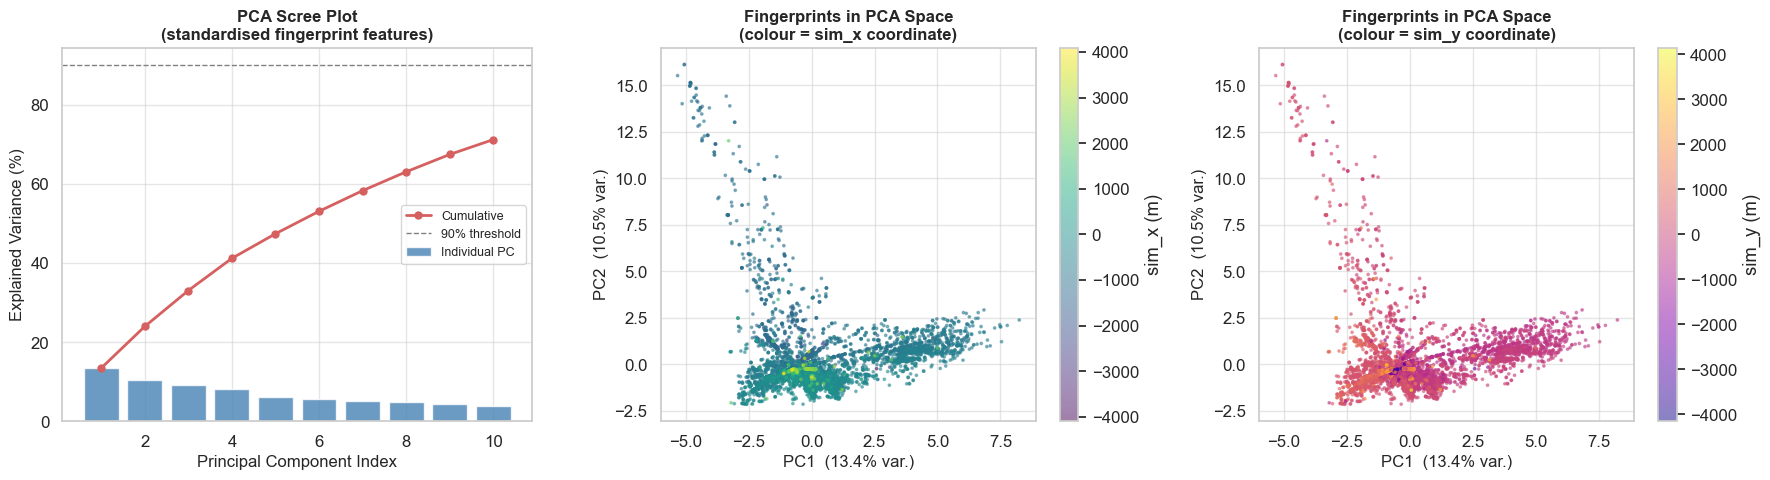


Spatial coherence check (Spearman ρ between PC scores and coordinates):
  PC1:  ρ(sim_x) = +0.128,   ρ(sim_y) = -0.412
  PC2:  ρ(sim_x) = -0.584,   ρ(sim_y) = -0.104
  PC3:  ρ(sim_x) = +0.209,   ρ(sim_y) = +0.411


In [45]:
# Standardise: zero-mean, unit-variance per cell dimension.
# Rationale: different cells have systematically different mean RSRP levels;
# standardisation ensures each cell contributes equally to the PCA geometry.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_fp)

n_components = min(10, len(cell_cols))
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Scree plot —
ax = axes[0]
ev    = pca.explained_variance_ratio_ * 100
cumev = np.cumsum(ev)
ax.bar(range(1, n_components + 1), ev, color='steelblue', alpha=0.8, label='Individual PC')
ax.plot(range(1, n_components + 1), cumev, 'r-o', lw=2, ms=5, label='Cumulative')
ax.axhline(90, color='gray', linestyle='--', lw=1, label='90% threshold')
ax.set_xlabel('Principal Component Index', fontsize=12)
ax.set_ylabel('Explained Variance (%)', fontsize=12)
ax.set_title('PCA Scree Plot\n(standardised fingerprint features)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

n90 = int(np.argmax(cumev >= 90) + 1)
print(f"Components for 90% explained variance : {n90}")
print(f"Variance explained by PC1             : {ev[0]:.1f}%")
print(f"Variance explained by PC2             : {ev[1]:.1f}%")
print(f"Cumulative (PC1 + PC2)                : {cumev[1]:.1f}%")

# — PC1 vs PC2, coloured by sim_x —
ax2 = axes[1]
sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1],
                  c=fp_db['sim_x'].values, cmap='viridis',
                  s=3, alpha=0.5, rasterized=True)
plt.colorbar(sc2, ax=ax2, label='sim_x (m)')
ax2.set_xlabel(f'PC1  ({ev[0]:.1f}% var.)', fontsize=12)
ax2.set_ylabel(f'PC2  ({ev[1]:.1f}% var.)', fontsize=12)
ax2.set_title('Fingerprints in PCA Space\n(colour = sim_x coordinate)', fontsize=12, fontweight='bold')

# — PC1 vs PC2, coloured by sim_y —
ax3 = axes[2]
sc3 = ax3.scatter(X_pca[:, 0], X_pca[:, 1],
                  c=fp_db['sim_y'].values, cmap='plasma',
                  s=3, alpha=0.5, rasterized=True)
plt.colorbar(sc3, ax=ax3, label='sim_y (m)')
ax3.set_xlabel(f'PC1  ({ev[0]:.1f}% var.)', fontsize=12)
ax3.set_ylabel(f'PC2  ({ev[1]:.1f}% var.)', fontsize=12)
ax3.set_title('Fingerprints in PCA Space\n(colour = sim_y coordinate)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/eda_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# Spatial coherence: Spearman rank correlation of PCs with geographic coordinates.
# High |ρ| means the radio feature gradient aligns with the geographic gradient —
# a necessary condition for WKNN to produce spatially meaningful estimates.
print("\nSpatial coherence check (Spearman ρ between PC scores and coordinates):")
for pc_idx in range(min(3, n_components)):
    r_x, _ = spearmanr(X_pca[:, pc_idx], fp_db['sim_x'].values)
    r_y, _ = spearmanr(X_pca[:, pc_idx], fp_db['sim_y'].values)
    print(f"  PC{pc_idx+1}:  ρ(sim_x) = {r_x:+.3f},   ρ(sim_y) = {r_y:+.3f}")

## 9. Key Findings and Design Decisions

The following table consolidates the empirical findings from this EDA and their direct implications for the WKNN pipeline implementation:

| # | Finding | Evidence | Pipeline Decision |
|---|---|---|---|
| 1 | **Simulation artefact** | 6 records with RSRP = 0 | Filter prior to M1 (build_fp_db) |
| 2 | **Referential integrity** | All 26 `gcell_id` values matched across both files | No orphan-ID handling required |
| 3 | **RSRP dynamic range** | ≈75 dB span (−117 to −42 dBm) | Sufficient for discriminative fingerprints; no range compression needed |
| 4 | **High fingerprint sparsity** | Large fraction of **F** matrix at −120 dBm fill | Adopt −120 dBm as noise-floor fill; masked-distance WKNN is a natural extension |
| 5 | **Cell-visibility heterogeneity** | ~42% of positions see only 1 cell | Expect elevated error in low-visibility zones; spatial error analysis in M3 is critical |
| 6 | **Query richness vs. real MRs** | No A3-event filtering → query vectors richer than real MRs | Report results as optimistic upper bound; document the sim-to-real gap explicitly |
| 7 | **Low intrinsic dimensionality** | Few PCs explain ≥90% of variance | Raw 26-D space has inter-cell redundancy; learned embedding (autoencoder/triplet) is a natural extension |
| 8 | **Spatial coherence confirmed** | PC1/PC2 exhibit smooth spatial gradients correlated with sim_x/sim_y | WKNN in fingerprint space is a valid proxy for geographic proximity |
| 9 | **Train/test split strategy** | 1,490 unique UEs; same UE can cover multiple positions | Split by UE (`GroupShuffleSplit`) to prevent positional data leakage into test set |